In [1]:
import numpy as np

import h5py
from tqdm import tqdm

from astropy.table import Table

import pandas as pd

import matplotlib.pyplot as plt

# write table to disk
from astropy.io import ascii


# Hydro

In [2]:
def import_hydro(file_number, directory):
    """Reads in data in the form of h5py files from TNG100
    Args:
        file_number: the desired number of files to be read in
        directory: string that details path from location
        of notebook to dataset, i.e. 'Data/hydro_data'
    Return:
        Outputs an astropy table with 'ID', 'SubhaloMass',
        'SubhaloFlag','StellarMass', 'x', 'y', 'z',
        'logSubhaloMass' and 'logStellarMass' as keys
    Note:
        'StellarMass' units Msun/h
        'logStellarMass' = log10('StellarMass')
    """
    subhalo_ids = []
    subhalo_mass = []
    subhalo_flag = []
    stellar_mass = []
    x_position = []
    y_position = []
    z_position = []
    count = 0

    for ii in tqdm(range(0, file_number + 1)):
        filename = f"{directory}/fof_subhalo_tab_099.{ii}.hdf5"
        with h5py.File(filename, "r") as f:
            if "SubhaloMass" in f["Subhalo"].keys():
                for s in f["Subhalo"]["SubhaloMass"]:
                    subhalo_mass.append(s)
                    subhalo_ids.append(count)
                    count += 1
                for flag in f["Subhalo"]["SubhaloFlag"]:
                    subhalo_flag.append(flag)
                for star in f["Subhalo"]["SubhaloMassInRadType"][:, 4]:
                    stellar_mass.append(star)
                for x, y, z in f["Subhalo"]["SubhaloPos"][:]:
                    x_position.append(x)
                    y_position.append(y)
                    z_position.append(z)

    t = Table(
        data=[
            subhalo_ids,
            subhalo_mass,
            subhalo_flag,
            stellar_mass,
            x_position,
            y_position,
            z_position,
        ],
        names=[
            "subfind_id",
            "SubhaloMass",
            "SubhaloFlag",
            "StellarMass",
            "x",
            "y",
            "z",
        ],
    )

    # Convert from TNG units to Msun/h
    t["StellarMass"] = t["StellarMass"] * 1e10
    t["SubhaloMass"] = t["SubhaloMass"] * 1e10

    # convert from ckpc/h to cMpc/h
    t["x"] = t["x"] / 1000
    t["y"] = t["y"] / 1000
    t["z"] = t["z"] / 1000
    return t

In [3]:
def import_color(directory):
    """Reads in color data from a given directory
    Args:
        directory: string that details path from location
    Return:
        Outputs pandas data fram with columns "sdss_u",
        "sdss_g", "sdss_r", "sdss_i", "sdss_z", "wfc_acs_f606w",
        "des_y", "jwst_f150w", and "subfind_id"

    Note: Use to compute "g - i" for red/blue galaxies
    """
    filename = (
        f"{directory}/Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc_099.hdf5"
    )
    f = h5py.File(filename, "r")
    colnames = (
        "sdss_u",
        "sdss_g",
        "sdss_r",
        "sdss_i",
        "sdss_z",
        "wfc_acs_f606w",
        "des_y",
        "jwst_f150w",
    )
    arr = f["Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc"][:]
    arr = np.mean(arr, axis=-1)  # averaging over projections
    df_color = pd.DataFrame(arr, columns=colnames)
    df_color["subfind_id"] = f["subhaloIDs"]
    return df_color

In [4]:
hydro_raw = import_hydro(447, "../../data/tng100")  # need to apply subhalo flag later

100%|██████████| 448/448 [01:02<00:00,  7.13it/s]


In [5]:
color_table = import_color("../../data")

In [6]:
len(hydro_raw), len(color_table)

(4371211, 4371211)

In [7]:
# they match exactly and ids too
np.all(hydro_raw["subfind_id"] == color_table["subfind_id"])

np.True_

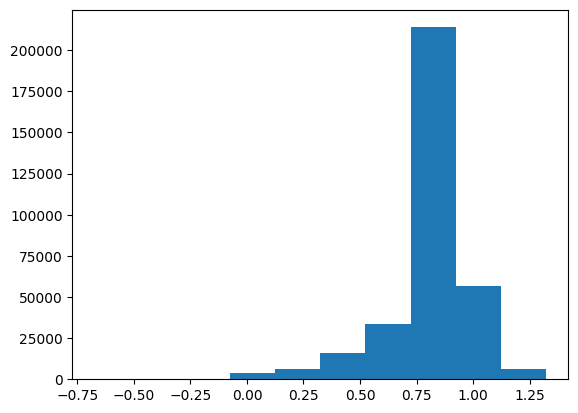

In [8]:
# so we just
hydro_raw["color"] = color_table["sdss_g"] - color_table["sdss_i"]
plt.hist(hydro_raw["color"]);

In [9]:
# # appply subhalo flag
# subhalo_flag_mask = hydro_raw['SubhaloFlag'] == 1
# hydro_full = hydro_raw[subhalo_flag_mask]
# len(hydro_full)

In [10]:
# now need to match with phil's data
tree_data = np.load("../../data/out-trees-tng100-bar.npz")
tree_data["subfind_id"].shape

(101431,)

In [11]:
id_mask = np.isin(hydro_raw["subfind_id"], tree_data["subfind_id"])
hydro_final = hydro_raw[id_mask]
len(hydro_final)

101431

In [12]:
# sort by subfind_id
hydro_final.sort(keys=("subfind_id"))
assert np.all(np.sort(hydro_final["subfind_id"]) == hydro_final["subfind_id"])

In [13]:
tree_data_sorted = {}
_sort_mask = np.argsort(tree_data["subfind_id"])
for k in tree_data:
    tree_data_sorted[k] = tree_data[k][_sort_mask]

assert np.all(np.sort(tree_data_sorted["subfind_id"]) == tree_data_sorted["subfind_id"])

In [14]:
for k in tree_data_sorted:
    print(k)

subfind_id
vpeak
vpeak_pre
is_sub
mpeak_pre
mpeak
stellar_mass
match_id
mpeak_mah
a12


In [15]:
assert np.all(tree_data_sorted["subfind_id"] == hydro_final["subfind_id"])

In [16]:
for k in tree_data_sorted:
    if k not in ("subfind_id",):
        hydro_final[k] = tree_data_sorted[k]

len(hydro_final)

101431

In [17]:
hydro_final[k] = tree_data_sorted[k]

len(hydro_final)

101431

In [18]:
assert np.all(hydro_final["StellarMass"] == hydro_final["stellar_mass"])  # sanity check

## Sanity checks

(array([   2.,    6.,   15.,   30.,   94.,  239.,  450.,  798., 1164.,
        1490., 1490., 1224.,  822.,  562.,  396.,  291.,  404.,  679.,
         815.,  290.,   55.]),
 array([0.07439804, 0.13347271, 0.19254738, 0.25162208, 0.31069672,
        0.36977142, 0.42884609, 0.48792076, 0.5469954 , 0.6060701 ,
        0.6651448 , 0.72421944, 0.78329414, 0.84236878, 0.90144348,
        0.96051812, 1.01959276, 1.07866752, 1.13774216, 1.1968168 ,
        1.25589156, 1.3149662 ]),
 <BarContainer object of 21 artists>)

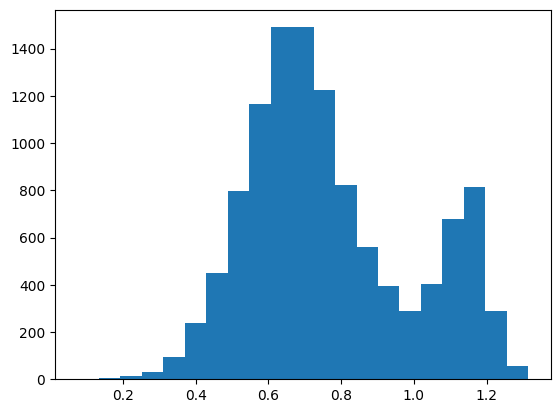

In [19]:
# color distribution is twice as nice
log_mpeak = np.log10(hydro_final["mpeak"])
mask = (log_mpeak > 11) & (log_mpeak < 12)

plt.hist(hydro_final["color"][mask], bins=21)


In [20]:
from scipy.stats import spearmanr

# should be ~60%
spearmanr(hydro_final["color"][mask], hydro_final["a12"][mask])

SignificanceResult(statistic=np.float64(-0.6247873809906019), pvalue=np.float64(0.0))

## Save final output

In [21]:
# write table to disk
from astropy.io import ascii

ascii.write(
    hydro_final, output="../../data/hydro_final.ecsv", format="ecsv", overwrite=True
)

# DMO hydro save

In [22]:
def import_dmo(file_number: int, directory):
    """Reads in data in the form of h5py files from TNG100
    Args:
        file_number: the desired number of files to be read in
        directory: string that details path from location
        of notebook to dataset, i.e. 'Data/hydro_data'
    Return:
        Outputs an astropy table with 'ID', 'SubhaloMass',
        'SubhaloFlag','StellarMass', 'x', 'y', 'z',
        'logSubhaloMass' and 'logStellarMass' as keys
    Note:
        'StellarMass' units Msun/h
        'logStellarMass' = log10('StellarMass')
    """
    subhalo_ids = []
    subhalo_mass = []
    x_position = []
    y_position = []
    z_position = []
    count = 0

    for ii in tqdm(range(0, file_number + 1)):
        filename = f"{directory}/fof_subhalo_tab_099.{ii}.hdf5"
        with h5py.File(filename, "r") as f:
            if "SubhaloMass" in f["Subhalo"].keys():
                for s in f["Subhalo"]["SubhaloMass"]:
                    subhalo_mass.append(s)
                    subhalo_ids.append(count)
                    count += 1
                for x, y, z in f["Subhalo"]["SubhaloPos"][:]:
                    x_position.append(x)
                    y_position.append(y)
                    z_position.append(z)

    t = Table(
        data=[
            subhalo_ids,
            subhalo_mass,
            x_position,
            y_position,
            z_position,
        ],
        names=[
            "subfind_id",
            "SubhaloMass",
            "x",
            "y",
            "z",
        ],
    )

    # Convert from TNG units to Msun/h
    t["SubhaloMass"] = t["SubhaloMass"] * 1e10

    # Create logSubhaloMass and logStellarMass
    t["logSubhaloMass"] = np.log10(t["SubhaloMass"])

    # convert from ckpc/h to cMpc/h
    t["x"] = t["x"] / 1000
    t["y"] = t["y"] / 1000
    t["z"] = t["z"] / 1000
    return t

In [23]:
dmo_raw = import_dmo(63, "../../data/tng100-dark/")
len(dmo_raw)

100%|██████████| 64/64 [00:08<00:00,  7.49it/s]


5012155

In [24]:
# now need to match with phil's data
tree_data = np.load("../../data/out-trees-tng100-dmo.npz")
tree_data["subfind_id"].shape

(533674,)

In [25]:
id_mask = np.isin(dmo_raw["subfind_id"], tree_data["subfind_id"])
dmo_final = dmo_raw[id_mask]
len(dmo_raw), len(dmo_final)

(5012155, 533674)

In [26]:
# sort by subfind_id
dmo_final.sort(keys=("subfind_id"))
assert np.all(np.sort(dmo_final["subfind_id"]) == dmo_final["subfind_id"])

In [27]:
tree_data_sorted = {}
_sort_mask = np.argsort(tree_data["subfind_id"])
for k in tree_data:
    tree_data_sorted[k] = tree_data[k][_sort_mask]

assert np.all(np.sort(tree_data_sorted["subfind_id"]) == tree_data_sorted["subfind_id"])

In [28]:
for k in tree_data_sorted:
    print(k)

subfind_id
vpeak_pre
vpeak
mpeak_pre
mpeak
is_sub
match_id
mah
mpeak_mah
a12


In [29]:
assert np.all(tree_data_sorted["subfind_id"] == dmo_final["subfind_id"])

In [30]:
for k in tree_data_sorted:
    if k not in ("subfind_id",):
        dmo_final[k] = tree_data_sorted[k]

len(dmo_final)

533674

In [31]:
dmo_final.keys()

['subfind_id',
 'SubhaloMass',
 'x',
 'y',
 'z',
 'logSubhaloMass',
 'vpeak_pre',
 'vpeak',
 'mpeak_pre',
 'mpeak',
 'is_sub',
 'match_id',
 'mah',
 'mpeak_mah',
 'a12']

In [32]:
# sanity
assert np.all(dmo_final["mah"][:, -1].data == dmo_final["SubhaloMass"])

In [35]:
# dmo out, since we will only use mpeak > 11 and mpeak < 12
# (and makes the .ecsv file much faster to load later!)
log_mpeak = np.log10(dmo_final["mpeak"])
mask = (log_mpeak > 11) & (log_mpeak < 12)
dmo_out = dmo_final[mask]
len(dmo_final), len(dmo_out)

(533674, 14181)

In [36]:
ascii.write(dmo_out, output="../../data/dmo_final.ecsv", format="ecsv", overwrite=True)